# Image Classification

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

In [18]:
# Load the fminst dataset
import tensorflow as tf
from tensorflow import keras

fasion_mnist = keras.datasets.fashion_mnist.load_data()

In [19]:
# Seprating the traning images from the test images and lebels
(train_images, train_labels), (test_images, test_labels) = fasion_mnist

In [20]:
# Shape of each dataset
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


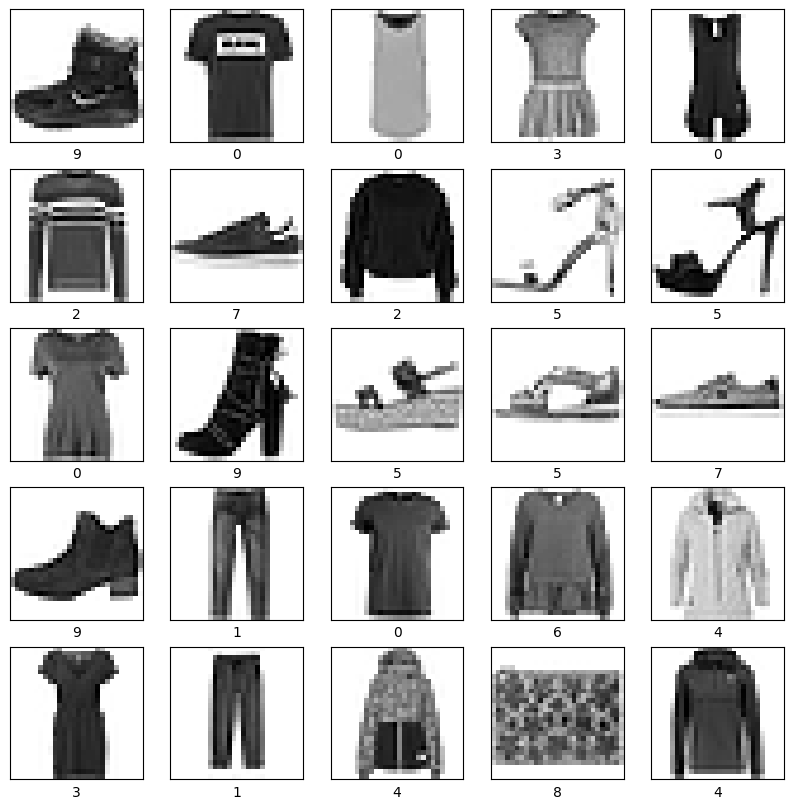

In [21]:
# Display some sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
plt.show()

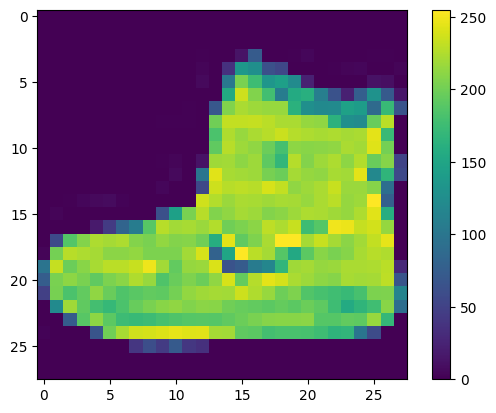

In [22]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [23]:
# Display the values of each pixel in the image
print("Pixel Values")
for row in train_images[0]:
    for pixel in row:
        print("{:3}".format(pixel), end=" ")
    print()

Pixel Values
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3 
  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15 
  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66 
  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 223 215

In [24]:
train_images = train_images/255
test_images = test_images/255

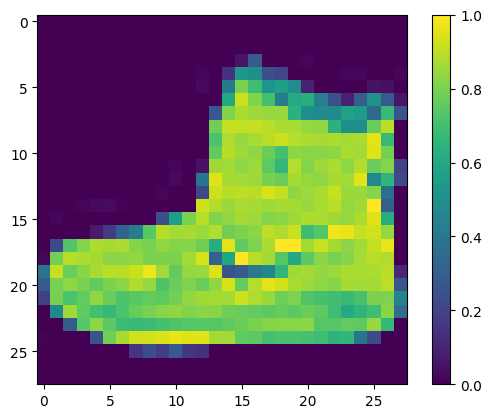

In [25]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

<Figure size 640x480 with 0 Axes>

<Axes: >

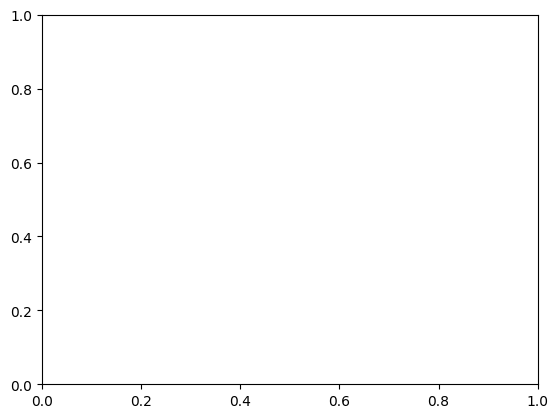

In [26]:
# reshape the dimension
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

# Display the complete output of the cell
from IPython.display import display
display(plt.gcf())
display(plt.gca())

In [27]:
# Create an input layer
import tensorflow as tf
from tensorflow.keras import layers

input_layer = tf.keras.layers.Input(shape=(28,28,1))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          54,090 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8371 - loss: 0.4676 - val_accuracy: 0.8680 - val_loss: 0.3739
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8876 - loss: 0.3242 - val_accuracy: 0.8813 - val_loss: 0.3336
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8987 - loss: 0.2894 - val_accuracy: 0.8989 - val_loss: 0.2917
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9059 - loss: 0.2662 - val_accuracy: 0.9032 - val_loss: 0.2799
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9123 - loss: 0.2474 - val_accuracy: 0.9006 - val_loss: 0.2826
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9177 - loss: 0.2330 - val_accuracy: 0.9039 - val_loss: 0.2762
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9228 - loss: 0.2187 - val_accuracy: 0.9083 - val_loss: 0.2648
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9258 -

In [29]:
# Model evaluation
test_loss, test_acc = model.evaluate(test_images,test_labels,verbose=2)
print('\nTest Accuracy : ',test_acc)
print('Test Loss : ',test_loss)

313/313 - 3s - 9ms/step - accuracy: 0.9016 - loss: 0.2844

Test Accuracy :  0.9016000032424927
Test Loss :  0.28436487913131714


In [30]:
# save the model
model.save('02_Fashion_mnist_model.h5')

# Make Prediction

In [32]:
test_images.shape

(10000, 28, 28, 1)

In [33]:
prediction = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [34]:
prediction[0]

array([3.7910006e-08, 4.0924120e-10, 7.2116302e-07, 2.0615715e-08,
       1.0451168e-07, 4.7279871e-04, 1.2475942e-06, 2.0987480e-03,
       9.6827134e-05, 9.9732947e-01], dtype=float32)

In [35]:
test_labels[0]

np.uint8(9)

In [36]:
np.argmax(prediction[0])

np.int64(9)

In [43]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict on test images
prediction = model.predict(test_images)

# Predicted class labels
predicted_labels = np.argmax(prediction, axis=1)

# True class labels
true_labels = test_labels

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


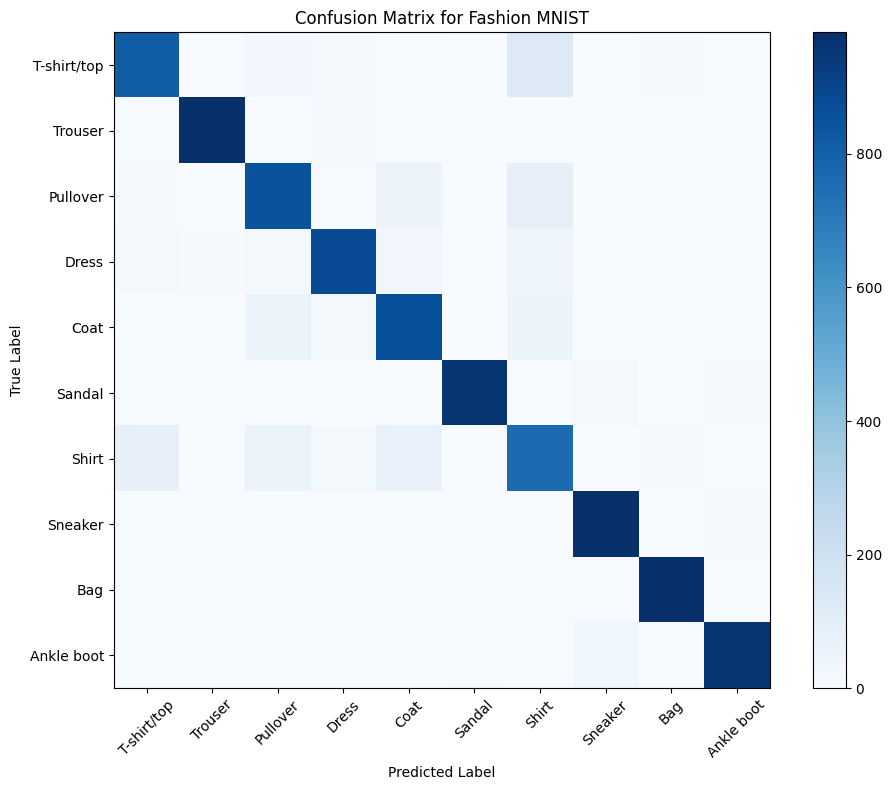

In [44]:
import matplotlib.pyplot as plt
import numpy as np

class_labels = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Fashion MNIST')
plt.colorbar()

tick_marks = np.arange(len(class_labels))

plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

C:\Users\2005a\AppData\Local\Temp\ipykernel_18212\1934849198.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


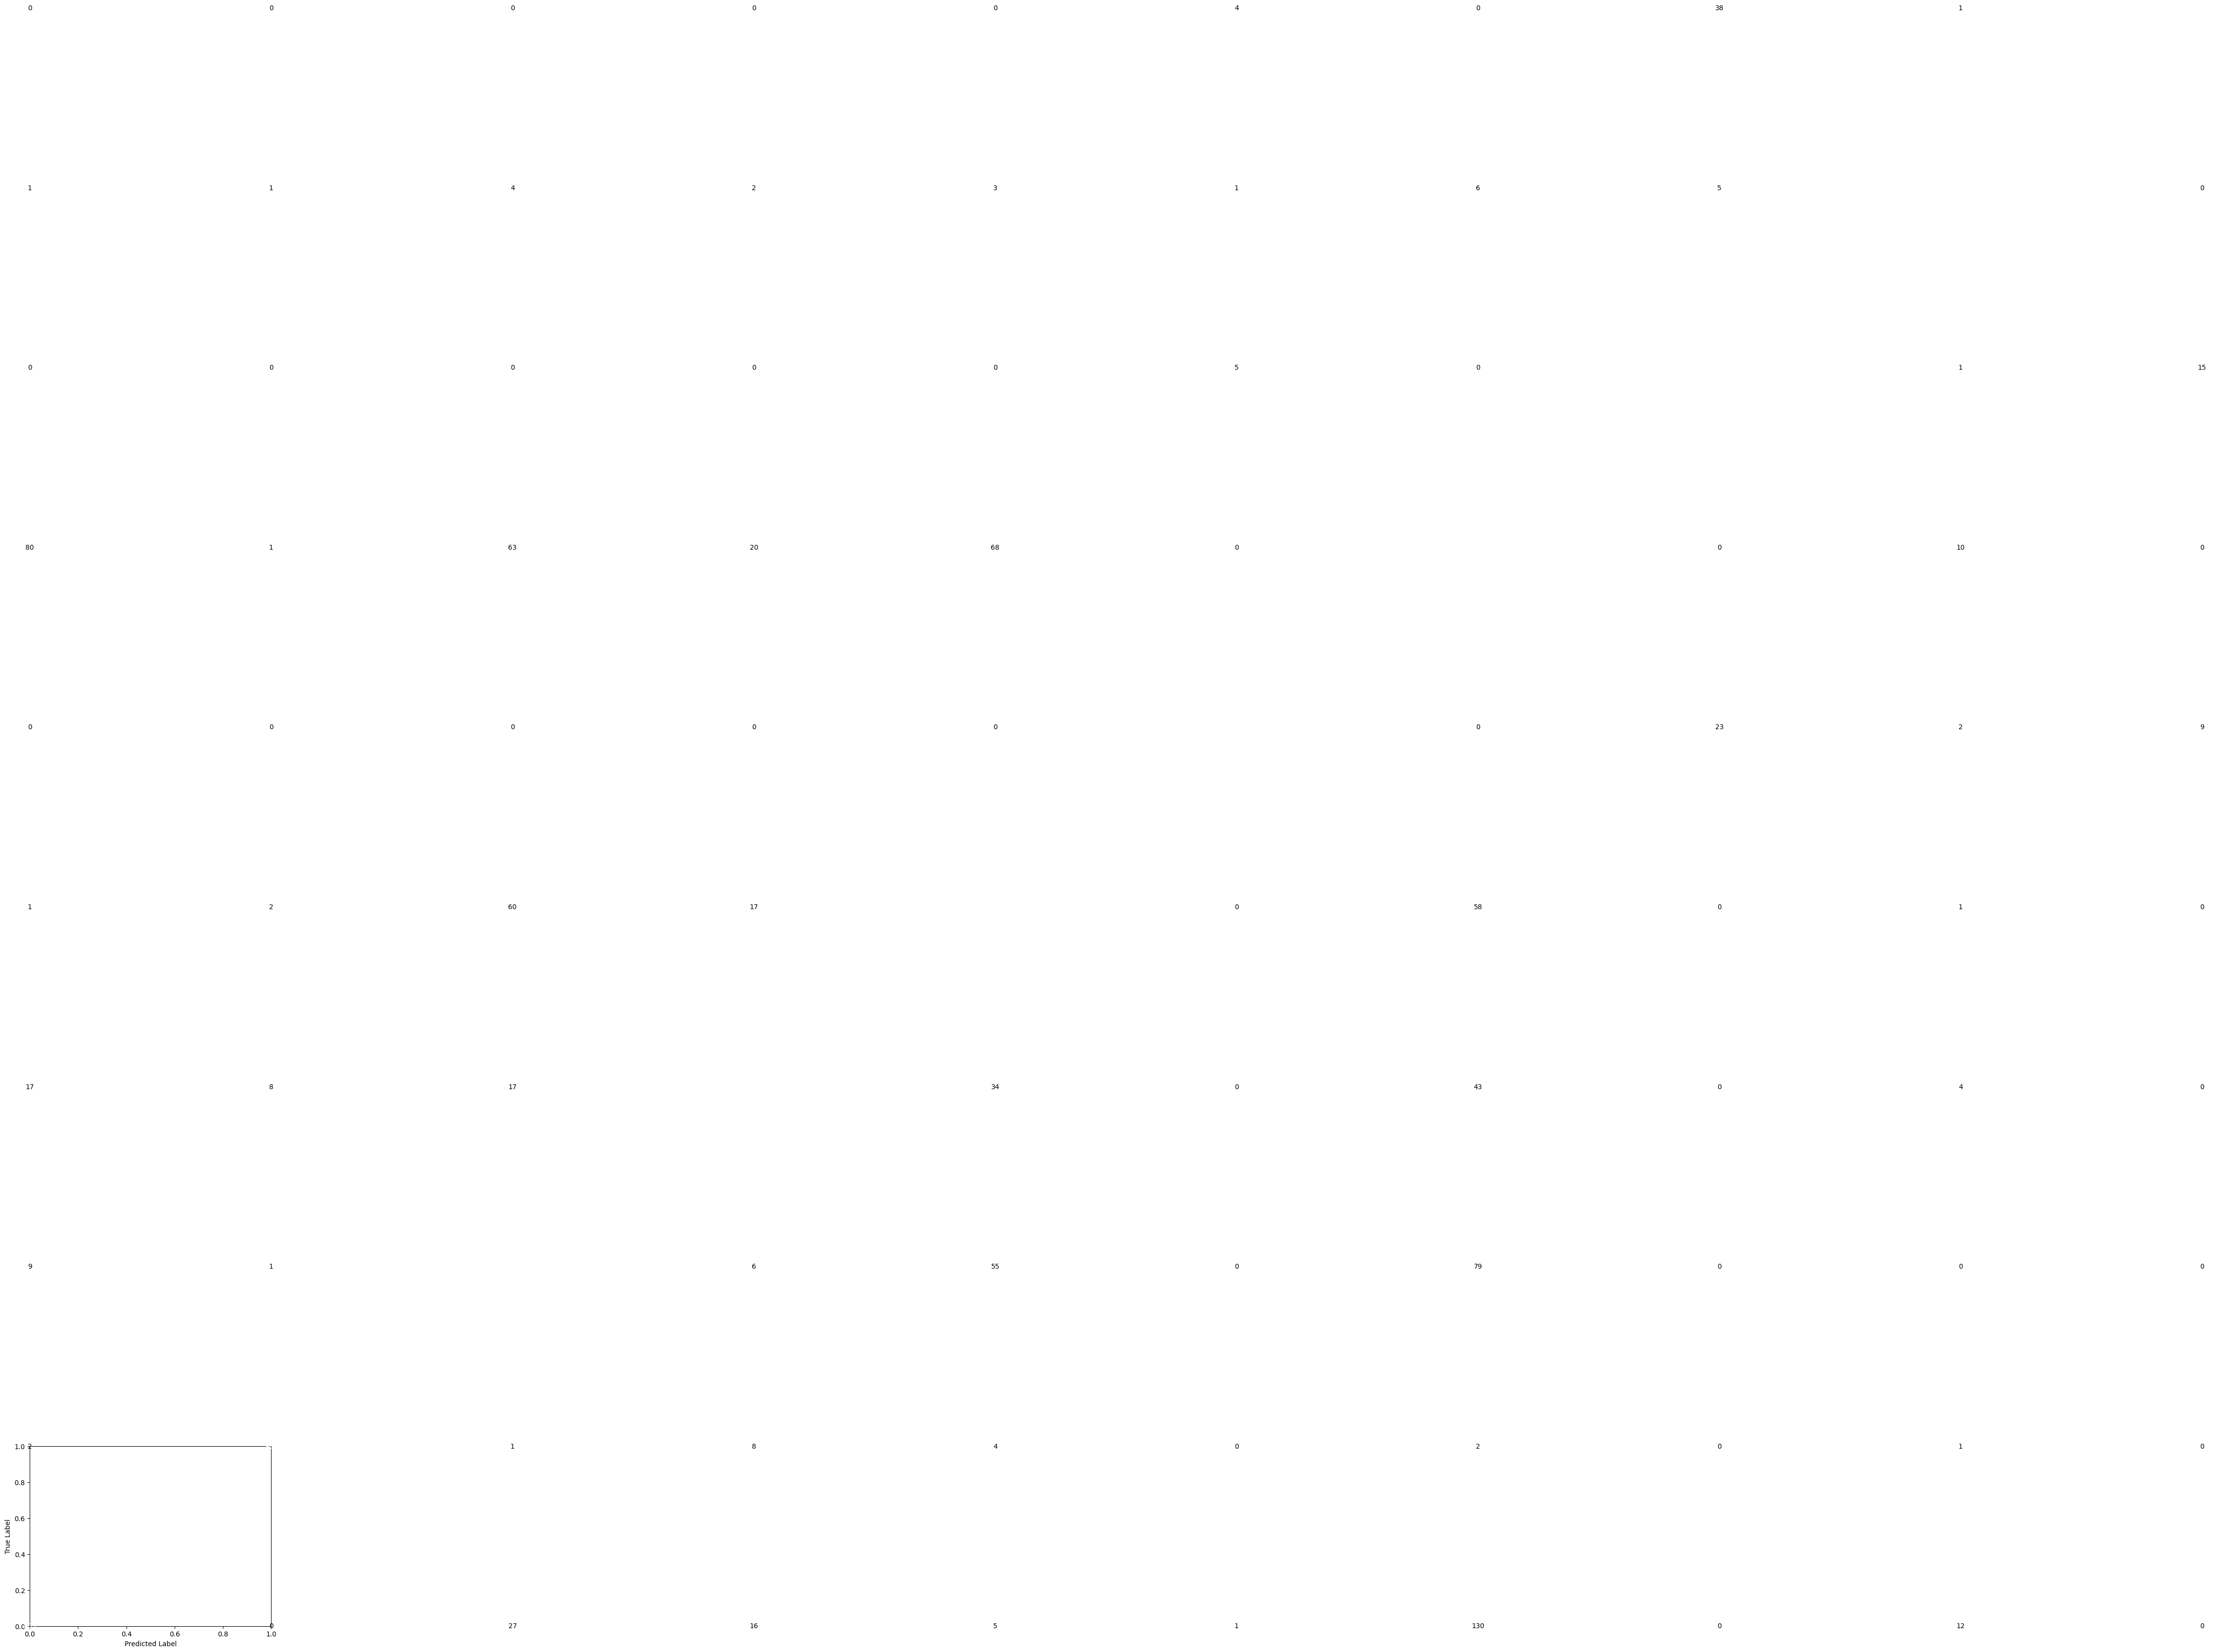

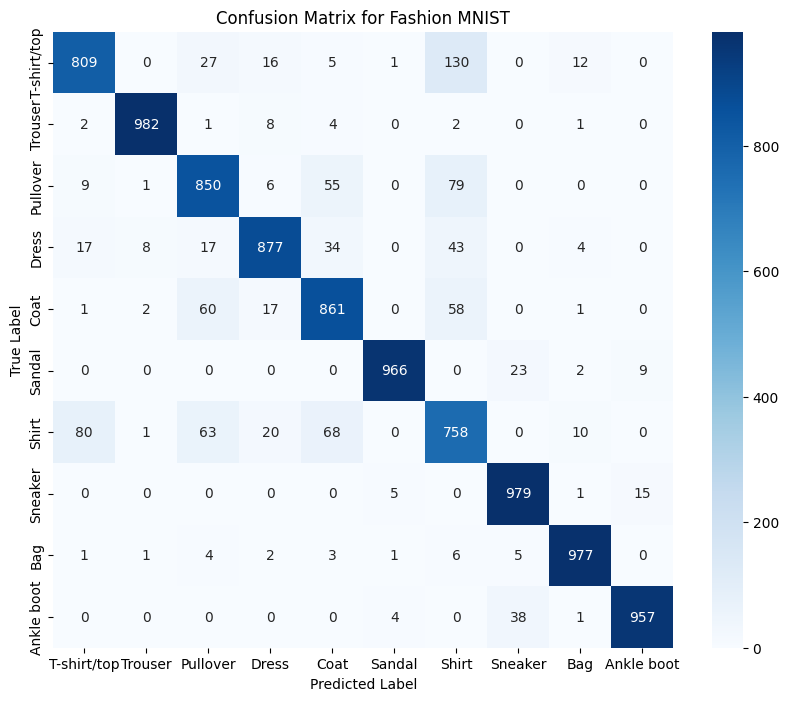

In [46]:
# Add values to the confusion matrix plot
thresh = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], 'd'),
            ha='center',
            va='center',
            color='white' if cm[i, j] > thresh else 'black'
        )

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
# Easier Method Using Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,      # show values
    fmt='d',         # integer format
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix for Fashion MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()